# Classification Multiclasse des Pneumonies

## Objectif

Après validation du pipeline en classification binaire (Normal vs Pneumonie),
nous étendons l’analyse vers une classification multiclasses :

- Normal
- Pneumonie Bactérienne
- Pneumonie Virale

L’objectif est d’évaluer la capacité du modèle à différencier deux types d’infections pulmonaires radiographiquement proches.

---

## Hypothèse

La distinction entre pneumonie bactérienne et virale sera significativement plus complexe que la simple détection d’anomalie.

Nous anticipons :

- Une baisse initiale des performances
- Une confusion entre Virus et Bacteria
- Une nécessité d’ajustements (class_weight, fine-tuning)

---

## Stratégie

1. Mise en place du modèle EfficientNet multiclasses
2. Entraînement baseline (sans ajustements)
3. Analyse confusion matrix & ROC
4. Ajustement progressif du modèle

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
import os
sys.path.append(os.path.abspath("../../src"))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from models.multiclass_model import build_efficientnet_multiclass, build_efficientnet_head_only
from data.data_loader_v3 import create_multiclass_generators
from visualization.data_exploration import plot_confusion_matrix, plot_multiclass_roc

from models.hierarchical_pipeline import HierarchicalClassifier


In [2]:
DATA_DIR = "../../data/raw/chest_Xray"

train_gen, test_gen, val_gen = create_multiclass_generators(DATA_DIR)

print("Classes détectées :", train_gen.class_indices)

print("Train distribution:", np.bincount(train_gen.classes))
print("test distribution:", np.bincount(test_gen.classes))
print("Validation distribution:", np.bincount(val_gen.classes))

Found 3469 images belonging to 3 classes.
Found 867 images belonging to 3 classes.
Found 1402 images belonging to 3 classes.
Classes détectées : {'1_NORMAL': 0, '2_BACTERIA': 1, '3_VIRUS': 2}
Train distribution: [1073 1640  756]
test distribution: [200 688 514]
Validation distribution: [268 410 189]


In [3]:
model = build_efficientnet_multiclass()
# model = build_efficientnet_head_only()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,046 (16.09 MB)

 Trainable params: 2,217,619 (8.46 MB)

 Non-trainable params: 2,001,427 (7.63 MB)

In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

classes = train_gen.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

{0: np.float64(1.077663870767319), 1: np.float64(0.7050813008130081), 2: np.float64(1.529541446208113)}
Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 66s 543ms/step - accuracy: 0.3897 - loss: 2.0638 - val_accuracy: 0.3783 - val_loss: 1.1294
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 58s 528ms/step - accuracy: 0.4105 - loss: 1.9883 - val_accuracy: 0.4279 - val_loss: 1.1130
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 59s 538ms/step - accuracy: 0.4307 - loss: 1.9189 - val_accuracy: 0.4521 - val_loss: 1.0995
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 59s 537ms/step - accuracy: 0.4240 - loss: 1.9060 - val_accuracy: 0.4960 - val_loss: 1.0762
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 54s 498ms/step - accuracy: 0.4635 - loss: 1.8050 - val_accuracy: 0.5294 - val_loss: 1.0498
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 55s 505ms/step - accuracy: 0.4673 - loss: 1.7356 - val_accuracy: 0.5536 - val_loss: 0.9925
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 53s 490ms/step - accuracy: 0.4860 - loss: 1.7043 - val_accuracy: 0.582

44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step
Modèle sauvegardé


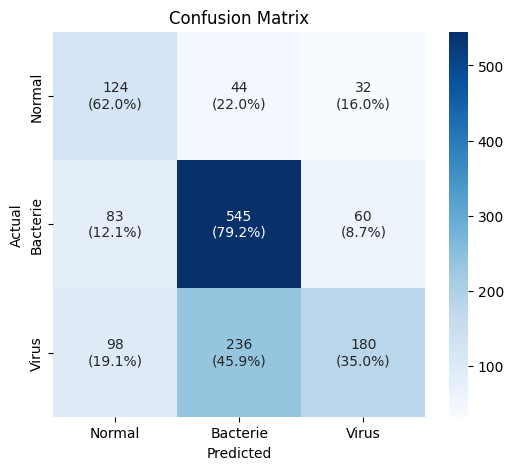


Classification Report:

              precision    recall  f1-score   support

           0       0.41      0.62      0.49       200
           1       0.66      0.79      0.72       688
           2       0.66      0.35      0.46       514

    accuracy                           0.61      1402
   macro avg       0.58      0.59      0.56      1402
weighted avg       0.62      0.61      0.59      1402



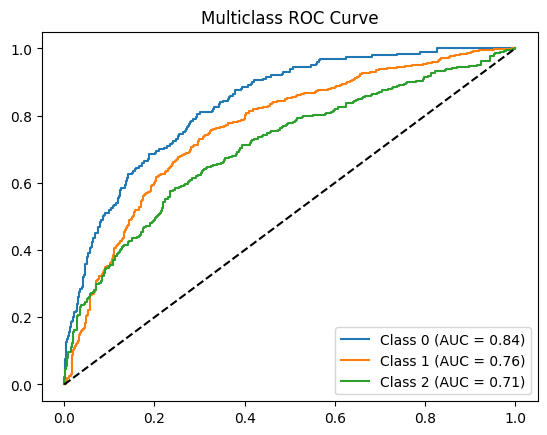

In [5]:
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("Modèle sauvegardé")
model.save("efficientnet_multiclass_stage1.keras")

y_pred = np.argmax(y_pred_probs, axis=1)

plot_confusion_matrix(y_true, y_pred)

plot_multiclass_roc(y_true, y_pred_probs, n_classes=3)

### Recharger le meilleur modèle

``` text/plain
model_load = models.load_model("efficientnet_multiclass_stage1.keras")
```

Rechargement du modèle...
44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 234ms/step


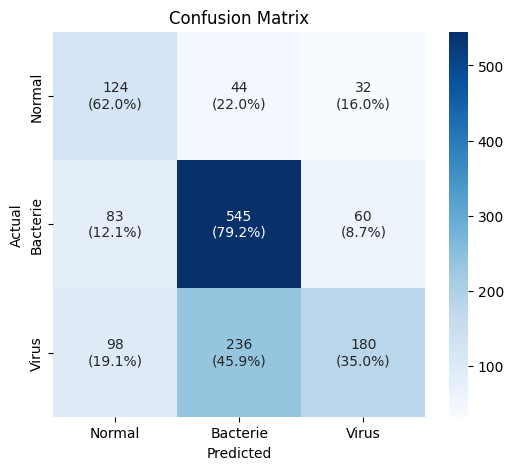


Classification Report:

              precision    recall  f1-score   support

           0       0.41      0.62      0.49       200
           1       0.66      0.79      0.72       688
           2       0.66      0.35      0.46       514

    accuracy                           0.61      1402
   macro avg       0.58      0.59      0.56      1402
weighted avg       0.62      0.61      0.59      1402



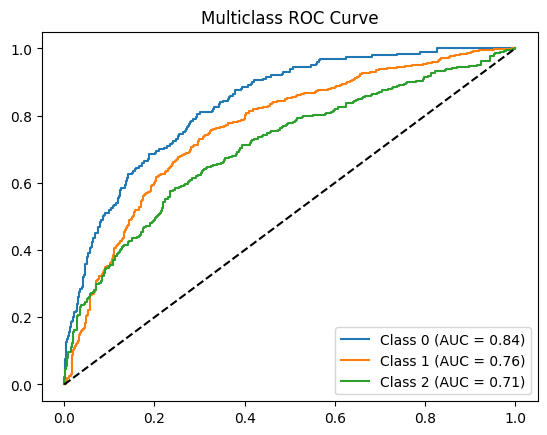

In [6]:
print(f"Rechargement du modèle...")
model_load = models.load_model("efficientnet_multiclass_stage1.keras")

y_true = test_gen.classes

y_pred_probs = model_load.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

plot_confusion_matrix(y_true, y_pred)

plot_multiclass_roc(y_true, y_pred_probs, n_classes=3)

## Dernière étape : pipeline binary into VIRUS & BACTERIE

In [8]:
classifier = HierarchicalClassifier(
    binary_model_path="efficientnet_binary_stage1.keras",
    subtype_model_path="efficientnet_multiclass_stage1.keras"
)

result = classifier.predict("../../data/raw/chest_Xray/test/3_VIRUS/person32_virus_71.jpeg")
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
{'final_prediction': 'BACTERIA', 'confidence': 0.28205162286758423, 'stage': 'hierarchical'}


['1_NORMAL', '2_BACTERIA', '3_VIRUS']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━

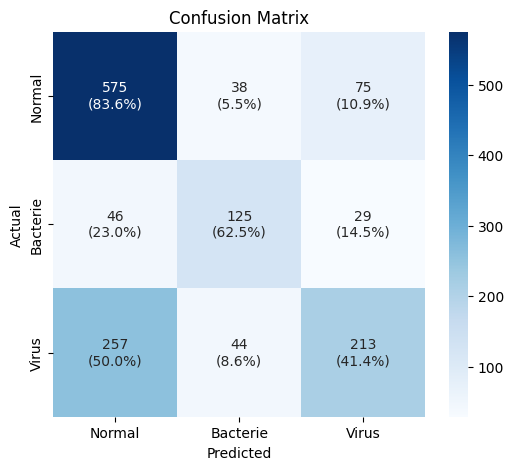


Classification Report:

              precision    recall  f1-score   support

    BACTERIA       0.65      0.84      0.73       688
      NORMAL       0.60      0.62      0.61       200
       VIRUS       0.67      0.41      0.51       514

    accuracy                           0.65      1402
   macro avg       0.64      0.63      0.62      1402
weighted avg       0.65      0.65      0.64      1402



In [11]:
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

true_labels = []
pred_labels = []

label_mapping = {
    "1_NORMAL": "NORMAL",
    "2_BACTERIA": "BACTERIA",
    "3_VIRUS": "VIRUS"
}

test_root = "../../data/raw/chest_Xray/test"

print(os.listdir(test_root))

for class_folder in os.listdir(test_root):
    class_path = os.path.join(test_root, class_folder)
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        result = classifier.predict(img_path)
        
        true_labels.append(label_mapping[class_folder])
        pred_labels.append(result["final_prediction"])

print(classification_report(true_labels, pred_labels))

plot_confusion_matrix(true_labels, pred_labels)
